# Model 2C, CatBoost Experiment 01: Arrival Delay After Takeoff

This experiment applies CatBoost to Logistic Regression 2C Experiment 01's exact 31-field allowlist. The model predicts `ArrDel15` immediately after takeoff at the flight origin. CatBoost handles airline and origin as native categorical fields and can learn nonlinear relationships among departure delay, taxi-out duration, schedule, route, planned traffic, and weather.

Hyperparameters and tree count are selected only from five expanding 2019 folds. The operating threshold is selected only from held-out 2019 probabilities. The selected model is refitted on all 2019 rows and evaluated once on 2023. The 2024 dataset is not loaded.

In [1]:
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "ArrDel15"

RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4
MAX_ITERATIONS = 1000
EARLY_STOPPING_ROUNDS = 75

In [2]:
from itertools import product
from pathlib import Path
from time import perf_counter

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"CatBoost version: {catboost.__version__}")

CatBoost version: 1.2.10


## Load and validate the shared arrival feature datasets

The experiment loads the same 2019 training dataset and 2023 validation dataset as Logistic Regression 2C Experiment 01. Each row is a flight destined for JFK. Cancelled and diverted flights were removed during source preparation.

In [3]:
def find_project_root(start: Path, airport: str, years) -> Path:
    required = [
        Path("data/features") / f"{airport}_{year}_arrivals.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required feature datasets: {required}")


PROJECT_ROOT = find_project_root(
    Path.cwd().resolve(),
    AIRPORT,
    [TRAIN_YEAR, VALIDATION_YEAR],
)
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_arrivals.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_arrivals.csv"

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "Dest", TARGET}
    missing = sorted(required.difference(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="raise")
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Dest"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107354,21784,0.2029
external validation,2023,2023-01-01,2023-12-31,365,109947,27077,0.2463


## Use the exact Logistic Regression 2C Experiment 01 allowlist

The allowlist contains the 27-field Model 2A base, signed `DepDelay` from Model 2B, and three post-takeoff fields: log taxi-out duration and cyclical actual takeoff time. CatBoost receives `Reporting_Airline` and `Origin` as native categorical fields. Numeric missing values remain `NaN`; missing categories receive the explicit value `MISSING`.

Raw `TaxiOut`, raw `WheelsOff`, target-flight arrival outcomes, and other post-takeoff outcomes are prohibited. They are not model inputs.

In [4]:
MODEL_2A_CATEGORICAL_FEATURES = [
    "Reporting_Airline",
    "Origin",
]

MODEL_2A_NUMERIC_FEATURES = [
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "IS_WEEKEND",
    "CRSElapsedTime",
    "LOG_DISTANCE",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "HourlyVisibility",
    "WindX",
    "WindY",
    "ADVERSE_WEATHER",
    "NOAA_AGE_MINUTES",
]

POST_PUSHBACK_FEATURES = ["DepDelay"]
POST_TAKEOFF_FEATURES = [
    "LOG_TAXI_OUT_MINUTES",
    "ACTUAL_TAKEOFF_TIME_SIN",
    "ACTUAL_TAKEOFF_TIME_COS",
]

categorical_features = list(MODEL_2A_CATEGORICAL_FEATURES)
numeric_features = [
    *MODEL_2A_NUMERIC_FEATURES,
    *POST_PUSHBACK_FEATURES,
    *POST_TAKEOFF_FEATURES,
]
feature_columns = [*categorical_features, *numeric_features]
required_columns = ["FlightDate", "Dest", "CRSDepTime", TARGET, *feature_columns]

assert len(MODEL_2A_CATEGORICAL_FEATURES + MODEL_2A_NUMERIC_FEATURES) == 27
assert len(feature_columns) == len(set(feature_columns)) == 31
assert len(categorical_features) == 2 and len(numeric_features) == 29

for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(required_columns).difference(frame.columns))
    assert not missing, f"{partition} missing required columns: {missing}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelayMinutes",
    "DepDel15",
    "DepartureDelayGroups",
    "ACTUAL_DEP_MINUTE_OF_DAY",
    "ACTUAL_DEP_TIME_SIN",
    "ACTUAL_DEP_TIME_COS",
    "DEPARTED_EARLY",
    "LOG_DEP_DELAY_MINUTES",
    "TaxiOut",
    "WheelsOff",
    "ACTUAL_TAKEOFF_MINUTE_OF_DAY",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrivalDelayGroups",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
assert not forbidden_predictors.intersection(feature_columns)

pd.Series({
    "source fields": len(feature_columns),
    "Model 2A base": 27,
    "post-pushback fields": len(POST_PUSHBACK_FEATURES),
    "post-takeoff fields": len(POST_TAKEOFF_FEATURES),
    "native categorical fields": len(categorical_features),
    "numeric fields": len(numeric_features),
})

source fields                31
Model 2A base                27
post-pushback fields          1
post-takeoff fields           3
native categorical fields     2
numeric fields               29
dtype: int64

## Prepare the model frames and chronological folds

No row is removed for a missing predictor. All 2019 arrival rows form the training dataset. Calendar days are divided into six consecutive blocks; five expanding-window folds train on earlier blocks and validate on the next block. The complete 2023 dataset is used only after the experiment design is fixed.

In [5]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in categorical_features:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in numeric_features:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)

X_train = train_model_df[feature_columns].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
X_validation = validation_model_df[feature_columns].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()

missing_summary = pd.DataFrame({
    "training_missing": X_train.isna().sum(),
    "validation_missing": X_validation.isna().sum(),
})
missing_summary[missing_summary.sum(axis=1).gt(0)]

,training_missing,validation_missing
ASPM_THREE_HOUR_SCHEDULED_DEPARTURES,14,10
ASPM_THREE_HOUR_SCHEDULED_ARRIVALS,14,10
ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC,1,0
ASPM_NEXT_MINUS_CURRENT_TRAFFIC,13,10
ASPM_MAX_HOURLY_TRAFFIC,14,10
HourlyDryBulbTemperature,6,6
TEMP_DEWPOINT_SPREAD,26,11
LOG_PRECIPITATION,12,19
HourlyVisibility,60,41
WindX,935,963


In [6]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized)))
    assert len(unique_days) >= n_splits + 1
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []

    for fold in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold])
        heldout_days = day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })

    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates,
    y_train,
    N_TIME_SPLITS,
)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17776,18725,2019-03-02,2019-03-03,2019-05-02,0.2082,0.1834
2,36501,18153,2019-05-02,2019-05-03,2019-07-02,0.1955,0.2319
3,54654,17703,2019-07-02,2019-07-03,2019-09-01,0.2076,0.2646
4,72357,17650,2019-09-01,2019-09-02,2019-11-01,0.2215,0.1474
5,90007,17347,2019-11-01,2019-11-02,2019-12-31,0.2070,0.1818


## Training-only CatBoost search

Sixteen compact candidates compare depths 4 and 6, learning rates 0.03 and 0.10, L2 leaf regularization 3 and 10, and no class weighting versus automatic balanced weighting. Each fold stops after 75 iterations without improvement in validation PRAUC. Mean average precision from held-out probabilities selects the configuration. The median fold-best tree count determines the final model size.

In [7]:
parameter_candidates = [
    {
        "depth": depth,
        "learning_rate": rate,
        "l2_leaf_reg": regularization,
        "class_weighting": class_weighting,
    }
    for depth, rate, regularization, class_weighting
    in product([4, 6], [0.03, 0.10], [3, 10], ["None", "Balanced"])
]


def make_catboost_model(parameters, iterations=MAX_ITERATIONS, use_best_model=True):
    return CatBoostClassifier(
        iterations=iterations,
        loss_function="Logloss",
        eval_metric="PRAUC:type=Classic",
        depth=parameters["depth"],
        learning_rate=parameters["learning_rate"],
        l2_leaf_reg=parameters["l2_leaf_reg"],
        auto_class_weights=(
            None if parameters["class_weighting"] == "None"
            else parameters["class_weighting"]
        ),
        random_seed=RANDOM_STATE,
        thread_count=N_JOBS,
        allow_writing_files=False,
        verbose=False,
        use_best_model=use_best_model,
    )


search_start = perf_counter()
search_rows = []

for candidate_number, parameters in enumerate(parameter_candidates, start=1):
    for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
        model = make_catboost_model(parameters)
        model.fit(
            X_train.iloc[train_idx],
            y_train.iloc[train_idx],
            cat_features=categorical_features,
            eval_set=(X_train.iloc[heldout_idx], y_train.iloc[heldout_idx]),
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            verbose=False,
        )
        probabilities = model.predict_proba(X_train.iloc[heldout_idx])[:, 1]
        search_rows.append({
            "candidate": candidate_number,
            "fold": fold_number,
            **parameters,
            "best_iteration": model.get_best_iteration() + 1,
            "average_precision": average_precision_score(
                y_train.iloc[heldout_idx], probabilities
            ),
            "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
            "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
        })
    print(f"Completed candidate {candidate_number}/{len(parameter_candidates)}: {parameters}")

search_seconds = perf_counter() - search_start
fold_search_results = pd.DataFrame(search_rows)
candidate_results = (
    fold_search_results
    .groupby(
        ["candidate", "depth", "learning_rate", "l2_leaf_reg", "class_weighting"],
        as_index=False,
    )
    .agg(
        mean_average_precision=("average_precision", "mean"),
        std_average_precision=("average_precision", "std"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_brier_score=("brier_score", "mean"),
        median_best_iteration=("best_iteration", "median"),
        min_best_iteration=("best_iteration", "min"),
        max_best_iteration=("best_iteration", "max"),
    )
    .sort_values(["mean_average_precision", "mean_roc_auc"], ascending=False)
)

best_candidate = candidate_results.iloc[0]
selected_parameters = {
    "depth": int(best_candidate["depth"]),
    "learning_rate": float(best_candidate["learning_rate"]),
    "l2_leaf_reg": float(best_candidate["l2_leaf_reg"]),
    "class_weighting": str(best_candidate["class_weighting"]),
}
selected_iterations = max(1, int(best_candidate["median_best_iteration"]))

print(f"Temporal search completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation AP: {best_candidate['mean_average_precision']:.4f}")
print(f"Selected parameters: {selected_parameters}")
print(f"Selected iteration count: {selected_iterations}")
candidate_results

Completed candidate 1/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


Completed candidate 2/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'class_weighting': 'Balanced'}


Completed candidate 3/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'class_weighting': 'None'}


Completed candidate 4/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'class_weighting': 'Balanced'}


Completed candidate 5/16: {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


...

Completed candidate 13/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


Completed candidate 14/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'Balanced'}


Completed candidate 15/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'class_weighting': 'None'}


Completed candidate 16/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'class_weighting': 'Balanced'}
Temporal search completed in 528.6 seconds
Best mean temporal-validation AP: 0.9102
Selected parameters: {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 10.0, 'class_weighting': 'None'}
Selected iteration count: 406


,candidate,depth,learning_rate,l2_leaf_reg,class_weighting,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score,median_best_iteration,min_best_iteration,max_best_iteration
10,11,6,0.0300,10,None,0.9102,0.0189,0.9555,0.0480,406.0000,180,995
4,5,4,0.1000,3,None,0.9100,0.0185,0.9550,0.0480,421.0000,57,647
7,8,4,0.1000,10,Balanced,0.9098,0.0188,0.9556,0.0560,325.0000,88,494
8,9,6,0.0300,3,None,0.9098,0.0193,0.9553,0.0482,369.0000,131,746
14,15,6,0.1000,10,None,0.9097,0.0194,0.9552,0.0481,249.0000,39,316
5,6,4,0.1000,3,Balanced,0.9093,0.0194,0.9549,0.0555,438.0000,48,468
11,12,6,0.0300,10,Balanced,0.9092,0.0191,0.9555,0.0550,559.0000,124,703
0,1,4,0.0300,3,None,0.9092,0.0192,0.9548,0.0483,596.0000,118,998
2,3,4,0.0300,10,None,0.9092,0.0187,0.9546,0.0482,612.0000,147,1000
15,16,6,0.1000,10,Balanced,0.9090,0.0200,0.9555,0.0553,101.0000,64,297


## Select the operating threshold using 2019 only

The selected parameters and fixed median tree count are refitted on each expanding training fold. Thresholds from 0.05 through 0.50 are ranked by F1 on held-out 2019 probabilities, with balanced accuracy and precision as tie-breakers. No 2023 outcome is used.

In [8]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_probabilities = np.full(len(y_train), np.nan)
for train_idx, heldout_idx in temporal_splits:
    fold_model = make_catboost_model(
        selected_parameters,
        iterations=selected_iterations,
        use_best_model=False,
    )
    fold_model.fit(
        X_train.iloc[train_idx],
        y_train.iloc[train_idx],
        cat_features=categorical_features,
        verbose=False,
    )
    oof_probabilities[heldout_idx] = fold_model.predict_proba(
        X_train.iloc[heldout_idx]
    )[:, 1]

oof_mask = np.isfinite(oof_probabilities)
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]

threshold_results = pd.DataFrame([
    evaluate_probabilities(oof_y, oof_p, threshold)
    for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2)
])
selected_threshold = float(
    threshold_results.sort_values(
        ["f1", "balanced_accuracy", "precision"],
        ascending=False,
    ).iloc[0]["threshold"]
)

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"],
    ascending=False,
).head(10)

Threshold-selection rows: 89,578
Training-only selected threshold: 0.37


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
32,0.3700,0.9383,0.8824,0.8931,0.7888,0.8377,0.8021,0.9552,0.9130,0.0480
34,0.3900,0.9387,0.8808,0.8998,0.7836,0.8377,0.8030,0.9552,0.9130,0.0480
30,0.3500,0.9378,0.8844,0.8854,0.7948,0.8377,0.8011,0.9552,0.9130,0.0480
31,0.3600,0.9380,0.8833,0.8892,0.7916,0.8376,0.8015,0.9552,0.9130,0.0480
33,0.3800,0.9384,0.8816,0.8962,0.7862,0.8376,0.8024,0.9552,0.9130,0.0480
28,0.3300,0.9372,0.8863,0.8773,0.8010,0.8374,0.7999,0.9552,0.9130,0.0480
27,0.3200,0.9369,0.8872,0.8738,0.8038,0.8373,0.7994,0.9552,0.9130,0.0480
36,0.4100,0.9390,0.8788,0.9065,0.7779,0.8373,0.8036,0.9552,0.9130,0.0480
29,0.3400,0.9374,0.8852,0.8812,0.7975,0.8373,0.8002,0.9552,0.9130,0.0480
35,0.4000,0.9388,0.8796,0.9032,0.7803,0.8372,0.8030,0.9552,0.9130,0.0480


## Refit on all 2019 rows and evaluate 2023

No 2023 outcome influences the allowlist, model search, tree count, or threshold. Logistic Regression 2C Experiment 01 is included as the documented fixed comparison and is not refitted here.

In [9]:
final_fit_start = perf_counter()
best_catboost_model = make_catboost_model(
    selected_parameters,
    iterations=selected_iterations,
    use_best_model=False,
)
best_catboost_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    verbose=False,
)
final_fit_seconds = perf_counter() - final_fit_start
validation_probabilities = best_catboost_model.predict_proba(X_validation)[:, 1]

evaluation_results = pd.DataFrame([
    {
        "model": "Logistic Regression 2C-01 (documented)",
        "threshold": 0.49,
        "accuracy": 0.9206,
        "balanced_accuracy": 0.8620,
        "precision": 0.9156,
        "recall": 0.7464,
        "f1": 0.8224,
        "mcc": 0.7786,
        "roc_auc": 0.9457,
        "average_precision": 0.9090,
        "brier_score": 0.0616,
    },
    {
        "model": "CatBoost 2C-01 (default)",
        **evaluate_probabilities(y_validation, validation_probabilities, 0.50),
    },
    {
        "model": "CatBoost 2C-01 (training-selected)",
        **evaluate_probabilities(
            y_validation,
            validation_probabilities,
            selected_threshold,
        ),
    },
]).set_index("model")

print(
    f"Final all-2019 fit: {final_fit_seconds:,.1f} seconds; "
    f"trees: {best_catboost_model.tree_count_:,}"
)
evaluation_results

Final all-2019 fit: 10.3 seconds; trees: 406


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Logistic Regression 2C-01 (documented),0.4900,0.9206,0.8620,0.9156,0.7464,0.8224,0.7786,0.9457,0.9090,0.0616
CatBoost 2C-01 (default),0.5000,0.9193,0.8580,0.9193,0.7372,0.8182,0.7749,0.9461,0.9080,0.0626
CatBoost 2C-01 (training-selected),0.3700,0.9188,0.8704,0.8810,0.7750,0.8246,0.7747,0.9461,0.9080,0.0626


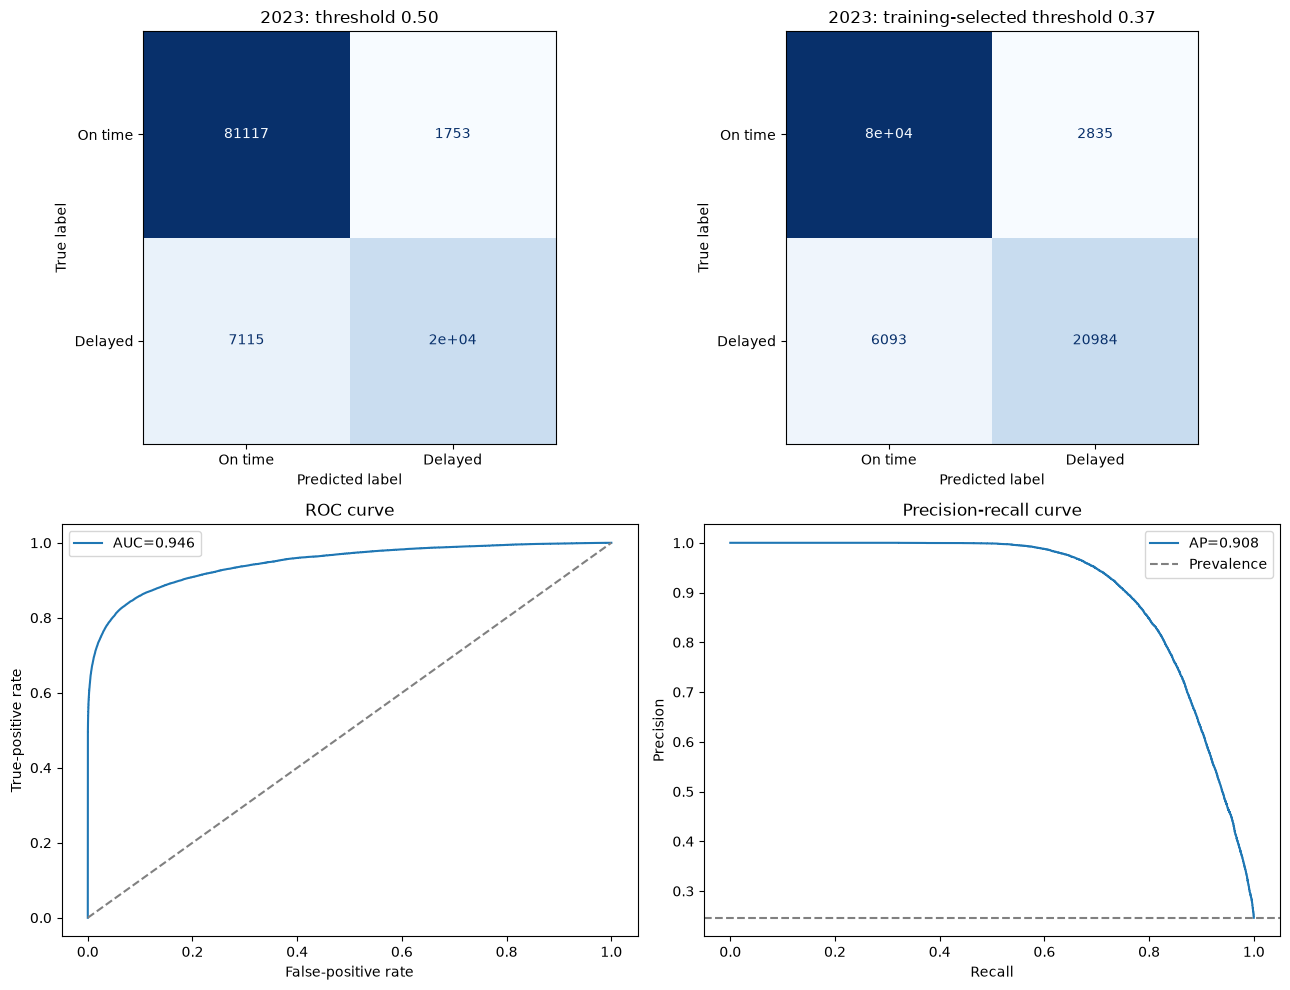

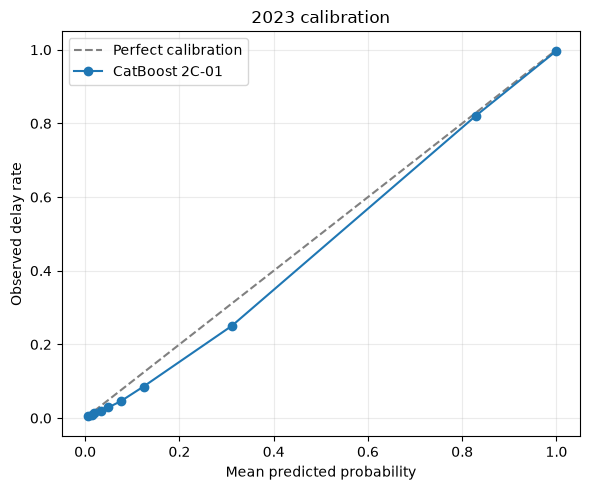

In [10]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_validation, validation_probabilities
)
curve_precision, curve_recall, _ = precision_recall_curve(
    y_validation, validation_probabilities
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"2023: training-selected threshold {selected_threshold:.2f}")
axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"AUC={roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="ROC curve",
)
axes[1, 0].legend()
axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=f"AP={average_precision_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 1].axhline(
    y_validation.mean(),
    linestyle="--",
    color="gray",
    label="Prevalence",
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision-recall curve",
)
axes[1, 1].legend()
fig.tight_layout()
plt.show()

predicted, observed = calibration_curve(
    y_validation,
    validation_probabilities,
    n_bins=10,
    strategy="quantile",
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label="CatBoost 2C-01")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
    title="2023 calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Inspect feature importance and publishable values

CatBoost importance describes predictive contribution within this fitted model. It does not establish that a field caused an arrival delay.

In [11]:
feature_importance = (
    pd.DataFrame({
        "feature": feature_columns,
        "importance": best_catboost_model.get_feature_importance(),
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance)

default = evaluation_results.loc["CatBoost 2C-01 (default)"]
selected = evaluation_results.loc["CatBoost 2C-01 (training-selected)"]
publishable_summary = pd.Series({
    "CatBoost version": catboost.__version__,
    "source fields": len(feature_columns),
    "native categorical fields": len(categorical_features),
    "numeric fields": len(numeric_features),
    "selected depth": selected_parameters["depth"],
    "selected learning rate": selected_parameters["learning_rate"],
    "selected L2 leaf regularization": selected_parameters["l2_leaf_reg"],
    "selected class weighting": selected_parameters["class_weighting"],
    "selected trees": selected_iterations,
    "training CV AP": best_candidate["mean_average_precision"],
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "search seconds": search_seconds,
    "final fit seconds": final_fit_seconds,
}, name="CatBoost 2C Experiment 01 Appendix F values")
publishable_summary.to_frame()

,feature,importance
0,DepDelay,48.7352
1,LOG_TAXI_OUT_MINUTES,17.7288
2,DAY_OF_YEAR_COS,5.4849
3,SCHEDULED_SPEED_PROXY,4.1863
4,DAY_OF_YEAR_SIN,4.1685
5,CRSElapsedTime,3.3097
6,LOG_DISTANCE,2.7853
7,Reporting_Airline,1.9035
8,SCHED_ARR_TIME_SIN,1.7480
9,SCHED_ARR_TIME_COS,1.3292


,CatBoost 2C Experiment 01 Appendix F values
CatBoost version,1.2.10
source fields,31
native categorical fields,2
numeric fields,29
selected depth,6
selected learning rate,0.0300
selected L2 leaf regularization,10.0000
selected class weighting,None
selected trees,406
training CV AP,0.9102


## Interpretation checklist

1. Does CatBoost improve mean 2019 temporal average precision over Logistic Regression 2C Experiment 01?
2. Does the training-selected design improve 2023 average precision, ROC AUC, Brier score, F1, or MCC?
3. Are any gains large enough to justify CatBoost's additional complexity?
4. Which fields carry the most predictive importance after takeoff?
5. Does CatBoost find useful nonlinear signal in actual takeoff time even though the logistic coefficients were small?
6. Keep the 2024 dataset untouched until the final classifier and threshold are selected.